In [1]:
import numpy as np

# Set random seed
np.random.seed(42)

In [2]:
from google.colab import drive
drive.mount("....")

Mounted at /content/drive


In [3]:
!pip install --pre deepchem
import deepchem
deepchem.__version__

INFO: pip is looking at multiple versions of deepchem to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of deepchem to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.0/610.0 kB 21.4 MB/s eta 0:00:00


wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.
Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead
wandb: WARNING W&B installed but not logged in.  Run `wandb login` or set the WANDB_API_KEY env variable.


'2.6.0.dev'

In [4]:
import pandas as pd

df=pd.read_excel(".....")
df.head()

,Molecule ChEMBL ID,Smiles,IC50,classLabel,IsValidSMILES,Morgan_FP,Molecule,Fingerprint,PCA1,PCA2,tSNE1,tSNE2,MolecularWeight,Frequency,cleanedMol
0,CHEMBL94,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e880b0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.738898,-1.494784,-52.761700,-42.736099,275.352,27,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C
1,CHEMBL207777,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88190>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.014164,-1.325272,-63.027809,-53.765778,325.364,1,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
2,CHEMBL205967,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.0,0,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88270>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,-1.235565,-1.559108,-61.968063,-54.078575,263.293,1,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2
3,CHEMBL60119,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e88430>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,2.705664,0.148113,57.758297,-8.911607,212.296,4,Cc1ccc2c(N)c3c(nc2c1)CCCC3
4,CHEMBL294525,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.0,1,True,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,<rdkit.Chem.rdchem.Mol object at 0x7bcfd8e884a0>,<rdkit.DataStructs.cDataStructs.ExplicitBitVec...,3.600017,-0.978574,61.242554,5.783804,341.455,3,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2


In [5]:
df['classLabel'].value_counts()

,count
classLabel,
0,2330
1,1747


In [6]:
df_selected= df[['cleanedMol', 'IC50']]
df_selected

,cleanedMol,IC50
0,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,28.00
1,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,97.00
2,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,2420.00
3,Cc1ccc2c(N)c3c(nc2c1)CCCC3,100.00
4,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,290.00
...,...,...
4072,O=C(Nc1ccc(CN2CCOCC2)cc1C(=O)C(=O)n1c(O)ccc1O)...,229.08
4073,COc1cccc2c1C=[N+](c1ccccc1C(F)(F)F)CC2,10000.00
4074,COc1cccc2cc[n+](-c3ccc(C)cc3)cc12,1080.00
4075,COc1ccc(-[n+]2ccc3cccc(OC)c3c2)cc1,140.00


In [7]:
df_selected['IC50'] = np.log(df_selected['IC50'])


/tmp/ipython-input-2280541905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected['IC50'] = np.log(df_selected['IC50'])


In [8]:
df_selected

,cleanedMol,IC50
0,CNC(=O)Oc1ccc2c(c1)[C@]1(C)CCN(C)[C@@H]1N2C,3.332205
1,Cc1ccccc1NC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,4.574711
2,CCNC(=O)Oc1ccc2c(c1)[C@]1(C)CO[C@@H](C1)O2,7.791523
3,Cc1ccc2c(N)c3c(nc2c1)CCCC3,4.605170
4,CCCCCCCNc1c2c(nc3cc([N+](=O)[O-])ccc13)CCCC2,5.669881
...,...,...
4072,O=C(Nc1ccc(CN2CCOCC2)cc1C(=O)C(=O)n1c(O)ccc1O)...,5.434071
4073,COc1cccc2c1C=[N+](c1ccccc1C(F)(F)F)CC2,9.210340
4074,COc1cccc2cc[n+](-c3ccc(C)cc3)cc12,6.984716
4075,COc1ccc(-[n+]2ccc3cccc(OC)c3c2)cc1,4.941642


In [9]:
pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.1/36.1 MB 38.2 MB/s eta 0:00:00


In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_style('white')

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw, PyMol, rdFMCS
from rdkit.Chem.Draw import IPythonConsole
from rdkit import rdBase
import numpy as np

In [11]:
df_selected.to_csv(".....", index=False)

In [12]:
import deepchem as dc

In [13]:
dataset_file = 'inhibitor.csv'
task = ['IC50']
featurizer_func = dc.feat.ConvMolFeaturizer()

loader = dc.data.CSVLoader(tasks=task, feature_field='cleanedMol', featurizer=featurizer_func)
dataset = loader.create_dataset(dataset_file)

Streaming output truncated to the last 5000 lines.
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)
[06:55:09] DEPRECATION WARNING: please use GetValence(getExplicit=False)


In [14]:
transformer = dc.trans.BalancingTransformer(dataset=dataset)
dataset = transformer.transform(dataset)

In [15]:
from rdkit import Chem

In [16]:
!pip install transformers

In [17]:
pip install simpletransformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.8/330.8 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 82.9 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=5108d5462b8c9a1796d5878b1ede5cd276f8be69ec633b32a4eff48e728882eb
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval


In [18]:
from simpletransformers.classification import ClassificationModel
import logging
logging.basicConfig(level=logging.INFO)
transformers_logger = logging.getLogger("transformers")
transformers_logger.setLevel(logging.WARNING)

from simpletransformers.classification import ClassificationModel, ClassificationArgs

model = ClassificationModel('roberta', 'DeepChem/ChemBERTa-77M-MTR', args={'evaluate_each_epoch': True, 'evaluate_during_training_verbose': True, 'no_save': True, 'num_train_epochs': 10, 'auto_weights': True}) # You can set class weights by using the optional weight argument

In [19]:
import deepchem as dc
import pandas as pd


task = ['classLabel']

dataset = dc.data.NumpyDataset(X=df_selected['cleanedMol'], y=df_selected['IC50'])

splitter = dc.splits.RandomSplitter()
frac_train = 0.7
frac_valid = 0.15
frac_test = 0.15

# Split the dataset
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset, frac_train=frac_train, frac_valid=frac_valid, frac_test=frac_test
)




In [20]:
test_dataset

<NumpyDataset X.shape: (612,), y.shape: (612,), w.shape: (612,), ids: [3356 2744 3859 ... 860 3507 3174], task_names: [0]>

In [21]:
train_df = train_dataset.to_dataframe()
valid_df = valid_dataset.to_dataframe()
test_df = test_dataset.to_dataframe()

In [22]:
train_df

,X,y,w,ids
0,Clc1ccc(CN2CCN(c3nccc(NCc4ccccc4)n3)CC2)cc1,9.913438,1.0,1749
1,CCCCNC(=O)Oc1cccc(CN(C)CCCOc2ccc3ccc(=O)oc3c2)c1,2.639057,1.0,2053
2,Cc1cccc(C[n+]2ccc(C(=O)NCCc3c[nH]c4ccccc34)cc2)c1,7.901007,1.0,538
3,CN(C)CCCCCCCCCCCCNc1c2c(nc3ccccc13)CCCC2,5.575949,1.0,438
4,COc1cc2c(cc1OC)SC(C(=O)CCc1cc[n+](Cc3ccsc3)cc1)C2,1.791759,1.0,2685
...,...,...,...,...
2848,CC1=Nc2nc3c(c(N)c2C(c2ccccc2F)C1C(=O)OC1CCC1)C...,6.629363,1.0,2927
2849,COc1cc2c(cc1OC)C(c1ccccc1)N(CCCCCCc1cc(C)nc(C=...,12.611538,1.0,375
2850,CC1CN(C(=O)Oc2ccc(Oc3ccc(C(F)(F)F)cn3)cc2)CC(C)O1,10.819778,1.0,1908
2851,CN(C)Cc1ccc(CSCCCCCCCCCCSCc2ccc(CN(C)C)o2)o1,7.170120,1.0,333


In [23]:
train_df=train_df[['X','y']]
valid_df=valid_df[['X','y']]
test_df=test_df[['X','y']]

In [24]:
import deepchem as dc
import pandas as pd
from rdkit import Chem
from deepchem.feat import MolGraphConvFeaturizer

smiles = df_selected["cleanedMol"].values
labels = df_selected["IC50"].values

featurizer = MolGraphConvFeaturizer()
features = featurizer.featurize(smiles)

# Build DeepChem dataset
dataset = dc.data.NumpyDataset(X=features, y=labels)

# Split (70/15/15)
splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset, frac_train=0.7, frac_valid=0.15, frac_test=0.15
)


In [25]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 11.1 MB/s eta 0:00:00


In [26]:
# ===============================
# ChemBERTa Regression + Optuna
# ===============================

import deepchem as dc
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from transformers import AutoTokenizer, RobertaModel
import optuna

# ---------- CONFIG ----------
CSV_PATH = "inhibitor.csv"
SMILES_COL = "cleanedMol"
TARGET_COL = "IC50"
CHEMBERTA_MODEL_NAME = "DeepChem/ChemBERTa-10M-MTR"
MAX_LEN = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Fractions for splitting
frac_train = 0.7
frac_valid = 0.15
frac_test = 0.15
# ----------------------------

# ---------- Load dataset ----------
df = pd.read_csv(CSV_PATH)[[SMILES_COL, TARGET_COL]].dropna().reset_index(drop=True)

# Shuffle dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

n_total = len(df)
n_train = int(frac_train * n_total)
n_valid = int(frac_valid * n_total)
n_test = n_total - n_train - n_valid

train_df = df.iloc[:n_train]
valid_df = df.iloc[n_train:n_train+n_valid]
test_df = df.iloc[n_train+n_valid:]

# ---------- Load ChemBERTa ----------
tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL_NAME)
bert_model = RobertaModel.from_pretrained(CHEMBERTA_MODEL_NAME).to(DEVICE)
bert_model.eval()  # freeze weights

# ---------- Convert SMILES to CLS embeddings ----------
def smiles_to_embedding(smiles_list):
    embeddings = []
    with torch.no_grad():
        for smi in smiles_list:
            smi = str(smi)
            inputs = tokenizer(
                smi,
                return_tensors="pt",
                truncation=True,
                padding="max_length",
                max_length=MAX_LEN
            ).to(DEVICE)
            outputs = bert_model(**inputs)
            cls_emb = outputs.last_hidden_state[:,0,:].cpu().numpy()
            embeddings.append(cls_emb.flatten())
    return np.array(embeddings)

X_train = smiles_to_embedding(train_df[SMILES_COL].tolist())
y_train = train_df[TARGET_COL].astype(float).to_numpy()

X_val = smiles_to_embedding(valid_df[SMILES_COL].tolist())
y_val = valid_df[TARGET_COL].astype(float).to_numpy()

X_test = smiles_to_embedding(test_df[SMILES_COL].tolist())
y_test = test_df[TARGET_COL].astype(float).to_numpy()

train_dataset = dc.data.NumpyDataset(X_train, y_train)
val_dataset = dc.data.NumpyDataset(X_val, y_val)

# ---------- Objective function ----------
def objective(trial):
    # Hyperparameter search space
    hidden1 = trial.suggest_int("hidden1", 128, 1024)
    hidden2 = trial.suggest_int("hidden2", 64, 512)
    dropout = trial.suggest_float("dropout", 0.0, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])

    n_features = X_train.shape[1]
    torch_model = nn.Sequential(
        nn.Linear(n_features, hidden1),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden1, hidden2),
        nn.ReLU(),
        nn.Linear(hidden2, 1)
    )

    optimizer = dc.models.optimizers.Adam(learning_rate=lr)

    model = dc.models.TorchModel(
        model=torch_model,
        loss=dc.models.losses.L2Loss(),
        optimizer=optimizer,
        batch_size=batch_size,
        model_dir= "/content/sample_data"  # avoid saving multiple models
    )

    model.fit(train_dataset, nb_epoch=20, deterministic=True)

    # Validation RMSE
    y_val_pred = model.predict(val_dataset).flatten()
    rmse = np.sqrt(np.mean((y_val - y_val_pred) ** 2))
    return rmse

# ---------- Run Optuna study ----------
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best trial:")
trial = study.best_trial
print(f"  RMSE: {trial.value:.4f}")
print(f"  Params: {trial.params}")

# ---------- Train final model with best params ----------
best_params = trial.params
n_features = X_train.shape[1]
torch_model = nn.Sequential(
    nn.Linear(n_features, best_params["hidden1"]),
    nn.ReLU(),
    nn.Dropout(best_params["dropout"]),
    nn.Linear(best_params["hidden1"], best_params["hidden2"]),
    nn.ReLU(),
    nn.Linear(best_params["hidden2"], 1)
)
optimizer = dc.models.optimizers.Adam(learning_rate=best_params["lr"])
final_model = dc.models.TorchModel(
    model=torch_model,
    loss=dc.models.losses.L2Loss(),
    optimizer=optimizer,
    batch_size=best_params["batch_size"],
    model_dir="chemberta_regression_final"
)

# Combine train + valid for final training
X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])
train_dataset_full = dc.data.NumpyDataset(X_full, y_full)
final_model.fit(train_dataset_full, nb_epoch=30)

# ---------- Evaluation ----------
test_dataset = dc.data.NumpyDataset(X_test, y_test)
y_pred = final_model.predict(test_dataset).flatten()
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"Test RMSE: {rmse:.4f}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-10M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

[I 2025-09-10 06:58:28,402] A new study created in memory with name: no-name-e1e1f975-1172-4132-8e53-8c7b4b18f9a0
/usr/local/lib/python3.12/dist-packages/deepchem/models/torch_models/torch_model.py:443: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  avg_loss = float(avg_loss) / averaged_batches
[I 2025-09-10 06:58:41,386] Trial 0 finished with value: 2.1596150810356805 and parameters: {'hidden1': 775, 'hidden2': 272, 'dropout': 0.2696924250508559, 'lr': 9.699543031848419e-05, 'batch_size': 16}. Best is trial 0 with value: 2.1596150810356805.
[I 2025-09-10 06:58:58,205] Trial 1 finished with value: 2.601077215327662 and parameters: {'hidden1': 231, 'hidden2': 398, 'dropout': 0.11459607992288551, 'lr': 2.259926912845088e-05, 'batch_size': 8}. Best is trial 0 with value: 2.1596150810356805.
[I 2025-

Best trial:
  RMSE: 2.0685
  Params: {'hidden1': 569, 'hidden2': 84, 'dropout': 0.3744541699572467, 'lr': 0.00029283123572936123, 'batch_size': 16}
Test RMSE: 1.9192


In [27]:


import shutil
shutil.make_archive("/content/my_folder", 'zip', "/content/sample_data")

from google.colab import files
files.download("/content/my_folder.zip")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

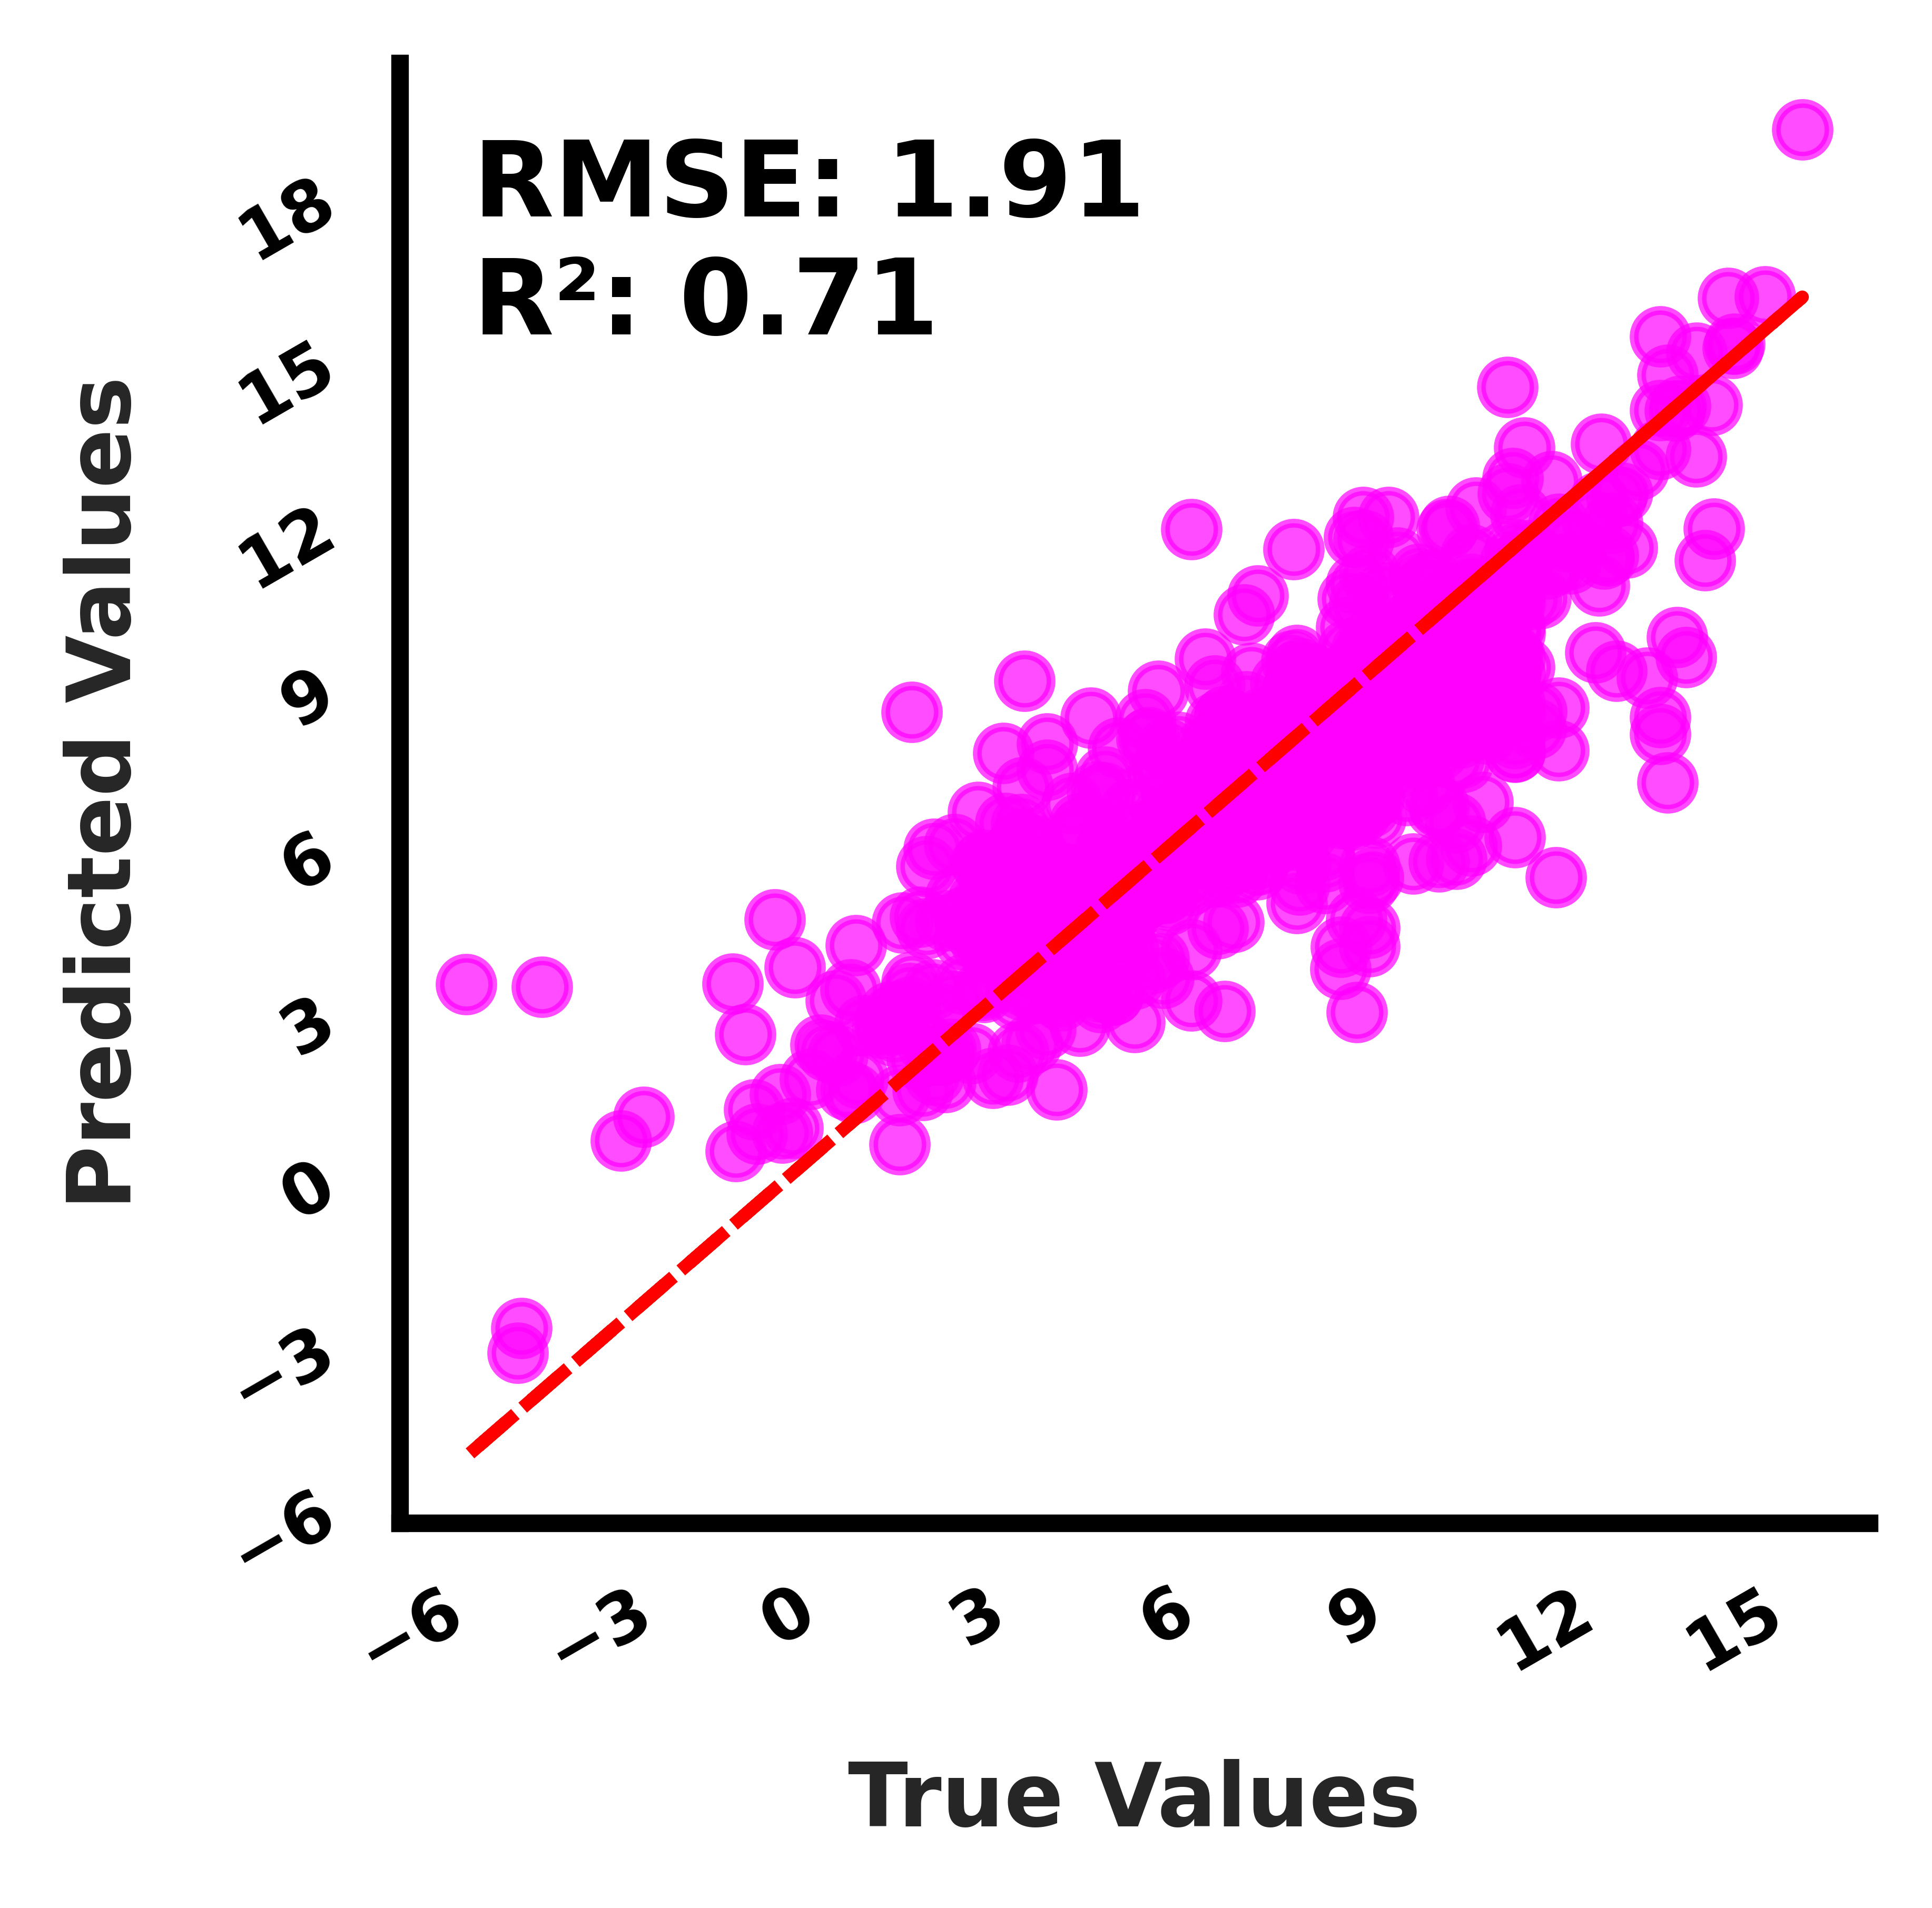

In [28]:
import deepchem as dc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.ticker import MaxNLocator

# ---------- CMYK to RGB ----------
def cmyk_to_rgb(c, m, y, k):
    r = 1 - min(1, c * (1 - k) + k)
    g = 1 - min(1, m * (1 - k) + k)
    b = 1 - min(1, y * (1 - k) + k)
    return (r, g, b)

pink_rgb = cmyk_to_rgb(0, 1, 0, 0)  # CMYK pink

# ---------- Dataset ----------
X_test = test_dataset.X
y_true = test_dataset.y.ravel()
dataset = dc.data.NumpyDataset(X=X_test, y=y_true)

# ---------- Predictions ----------
y_pred = final_model.predict(dataset).flatten()

# ---------- Metrics ----------
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

# ---------- Plot ----------
plt.rcParams.update({
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.weight': 'bold'
})

plt.figure(figsize=(3, 3), dpi=1200)
plt.scatter(y_true, y_pred, alpha=0.7, color=pink_rgb)
plt.plot(y_true, y_true, color='red', linestyle='--')

plt.xlabel('True Values', fontsize=10, weight='bold', labelpad=8)
plt.ylabel('Predicted Values', fontsize=10, weight='bold', labelpad=8)

ax = plt.gca()

# Keep integer ticks but add spacing so labels don’t overlap
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

# Increase space between ticks and labels
ax.tick_params(axis="x", pad=6)
ax.tick_params(axis="y", pad=6)

# Slight rotation to prevent overlap
plt.xticks(rotation=30, fontsize=8, weight='bold')
plt.yticks(rotation=30, fontsize=8, weight='bold')

# Customize axes
ax.tick_params(axis='both', which='both', direction='in', length=6, width=2, colors='black')
ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')

# Metrics
plt.text(0.05, 0.95, f'RMSE: {rmse:.2f}\nR²: {r2:.2f}',
         transform=ax.transAxes, fontsize=12,
         verticalalignment='top', color='black', weight='bold')

# Save figure
plt.savefig("test_predicted_vs_true_separated.tiff", format='tiff', dpi=2400, bbox_inches='tight')
plt.show()

# ---------- Save Metrics ----------
pd.DataFrame({'R2 Score': [r2], 'RMSE': [rmse]}, index=['Test']) \
    .to_excel(".....", index_label='Dataset')


In [ ]:
import os
import pandas as pd
import numpy as np
from rdkit import Chem
import deepchem as dc
import torch
from transformers import AutoTokenizer, RobertaModel

# ---------- CONFIG ----------
sdf_folder = "...."
CHEMBERTA_MODEL_NAME = "DeepChem/ChemBERTa-10M-MTR"
MAX_LEN = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------- Load ChemBERTa ----------
tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL_NAME)
bert_model = RobertaModel.from_pretrained(CHEMBERTA_MODEL_NAME).to(DEVICE)
bert_model.eval()  # freeze weights

# ---------- Function to convert SMILES to embeddings ----------
def smiles_to_embedding(smiles_list):
    embeddings = []
    with torch.no_grad():
        for smi in smiles_list:
            smi = str(smi)
            inputs = tokenizer(
                smi,
                return_tensors="pt",
                truncation=True,
                padding="max_length",
                max_length=MAX_LEN
            ).to(DEVICE)
            outputs = bert_model(**inputs)
            cls_emb = outputs.last_hidden_state[:,0,:].cpu().numpy()
            embeddings.append(cls_emb.flatten())
    return np.array(embeddings)

# ---------- Read SDF files ----------
molecule_files = [f for f in os.listdir(sdf_folder) if f.endswith(".sdf")]
names = []
smiles_list = []

for f in molecule_files:
    path = os.path.join(sdf_folder, f)
    suppl = Chem.SDMolSupplier(path)
    mols = [m for m in suppl if m is not None]
    if len(mols) > 0:
        mol = mols[0]
        smi = Chem.MolToSmiles(mol)
        smiles_list.append(smi)
        names.append(os.path.splitext(f)[0])

# ---------- Convert SMILES to embeddings ----------
X_pred = smiles_to_embedding(smiles_list)

# ---------- Predict regression values ----------
pred_dataset = dc.data.NumpyDataset(X_pred, np.zeros(len(X_pred)))
y_pred_log = final_model.predict(pred_dataset).flatten()

# ---------- Convert log(IC50) to real IC50 ----------
y_pred_real = np.exp(y_pred_log)

# ---------- Combine results ----------
results_df = pd.DataFrame({
    "Molecule": names,
    "SMILES": smiles_list,
    "Predicted_logIC50": y_pred_log,
    "Predicted_IC50": y_pred_real
})

# ---------- Save results ----------
results_df.to_excel(".....", index=False)
results_df


Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-10M-MTR and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,Molecule,SMILES,Predicted_logIC50,Predicted_IC50
0,Pipotiazine,CN(C)S(=O)(=O)c1ccc2c(c1)N(CCCN1CCC(CCO)CC1)c1...,7.665047,2132.492432
1,HuperzineA,C/C=C1\[C@H]2C=C(C)C[C@]1(N)c1ccc(=O)[nH]c1C2,3.383374,29.470049
2,Fluindione,O=C1c2ccccc2C(=O)C1c1ccc(F)cc1,8.758271,6363.101562
3,Dyclonine,CCCCOc1ccc(C(=O)CCN2CCCCC2)cc1,5.886358,360.091400
4,Donepezil,COc1cc2c(cc1OC)C(=O)[C@H](CC1CCN(Cc3ccccc3)CC1)C2,3.018670,20.464064
5,Demecarium,CN(CCCCCCCCCCN(C)C(=O)Oc1cccc([N+](C)(C)C)c1)C...,7.348255,1553.483521
6,CNP0019008,O=C(CN1CCC(CN2Cc3ccccc3C2=O)CC1)c1ccc(F)cc1,3.675539,39.469906
7,CNP0020024,CCc1ccccc1NC(=O)Oc1ccc2c(c1)[C@@]1(C)CC[N@@+](...,5.720610,305.090881
8,CNP0020767,O=c1ccc2c([nH]1)CCC[C@@H]2NCCCCCCCCCCNc1c2c(nc...,5.836802,342.681549
9,CNP0057604,Cc1cccc2c1CC2=O,4.490494,89.165497


In [ ]:
results_df.to_excel(".....", index=False)

from google.colab import files
files.download("molecule_predictions.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>